# Trabalho Final - notebook base do projeto da Mayra Arruda

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Pergunta de pesquisa

#### **Quais fatores (renda familiar anual, idade e escolaridade do chefe de família) estão mais associados aos hábitos de poupança e gastos das famílias?**

(renda familiar anual, idade do chefe de família, escolaridade do chefe de família, categorias de despesa, poupança)

--- Este trabalho utiliza o conjunto de dados *Family Income and Expenditure Survey (FIES)*, uma pesquisa domiciliar oficial e trienal conduzida pela Philippine Statistics Authority, com 41.544 domicílios e 60 colunas. **É importante destacar o recorte geográfico do dataset: todos os domicílios são das Filipinas** — não há dados de nenhum outro país, então qualquer conclusão vale apenas para essa população e não pode ser generalizada para outros contextos socioeconômicos.

Outro ponto importante é que a unidade de análise é o **domicílio**, não o indivíduo: a renda registrada é a renda **anual** de toda a família (não uma renda mensal individual), e as variáveis de idade e escolaridade dizem respeito especificamente à pessoa identificada como **chefe da família**, não a todos os moradores. Pretende-se avaliar como a renda familiar anual, a idade e a escolaridade do chefe de família se associam aos gastos por categoria e a uma medida de poupança que será derivada a partir dos dados (renda menos despesas), já que o dataset não traz uma coluna de poupança pronta.

In [2]:
# Carregando o dataset a partir do zip (contém um único CSV) e olhando as primeiras linhas
df = pd.read_csv("../datasets/mayra_arruda/family-income-and-expenditure.zip", compression='zip')

df.head()

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,1,1,0,0,0,2,1,0,0,1
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,1,0,0,0,3,1,0,0,2
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,0,0,0,0,0,0,0
3,107589,CAR,78189,Wage/Salaries,0,34030,28659,10914,10812,690,...,0,0,0,0,0,1,0,0,0,0
4,189322,CAR,94625,Wage/Salaries,0,34820,30167,18391,11309,1395,...,1,0,0,0,0,3,0,0,0,1


In [3]:
# Conferindo os nomes de todas as 60 colunas do dataset
df.columns

Index(['Total Household Income', 'Region', 'Total Food Expenditure',
       'Main Source of Income', 'Agricultural Household indicator',
       'Bread and Cereals Expenditure', 'Total Rice Expenditure',
       'Meat Expenditure', 'Total Fish and  marine products Expenditure',
       'Fruit Expenditure', 'Vegetables Expenditure',
       'Restaurant and hotels Expenditure', 'Alcoholic Beverages Expenditure',
       'Tobacco Expenditure', 'Clothing, Footwear and Other Wear Expenditure',
       'Housing and water Expenditure', 'Imputed House Rental Value',
       'Medical Care Expenditure', 'Transportation Expenditure',
       'Communication Expenditure', 'Education Expenditure',
       'Miscellaneous Goods and Services Expenditure',
       'Special Occasions Expenditure', 'Crop Farming and Gardening expenses',
       'Total Income from Entrepreneurial Acitivites', 'Household Head Sex',
       'Household Head Age', 'Household Head Marital Status',
       'Household Head Highest Grade Compl

## Padronizando os nomes das colunas

O dataset original tem nomes de coluna com espaços e capitalização mista (ex: `"Total Household Income"`, `"Household Head Highest Grade Completed"`). Antes de seguir, renomeio para nomes curtos e consistentes as colunas que serão efetivamente usadas na análise. De-para aplicado:

| Nome original | Novo nome | Uso |
|---|---|---|
| Total Household Income | Renda_Anual | variável da pergunta |
| Household Head Age | Idade_Chefe | variável da pergunta |
| Household Head Highest Grade Completed | Escolaridade_Chefe | variável da pergunta |
| Total Food Expenditure | Despesa_Alimentacao | compõe a poupança derivada |
| Housing and water Expenditure | Despesa_Moradia_Agua | compõe a poupança derivada |
| Medical Care Expenditure | Despesa_Saude | compõe a poupança derivada |
| Transportation Expenditure | Despesa_Transporte | compõe a poupança derivada |
| Communication Expenditure | Despesa_Comunicacao | compõe a poupança derivada |
| Education Expenditure | Despesa_Educacao | compõe a poupança derivada |
| Clothing, Footwear and Other Wear Expenditure | Despesa_Vestuario | compõe a poupança derivada |
| Miscellaneous Goods and Services Expenditure | Despesa_Diversos | compõe a poupança derivada |
| Special Occasions Expenditure | Despesa_Ocasioes_Especiais | compõe a poupança derivada |
| Alcoholic Beverages Expenditure | Despesa_Bebidas_Alcoolicas | compõe a poupança derivada |
| Tobacco Expenditure | Despesa_Tabaco | compõe a poupança derivada |
| Crop Farming and Gardening expenses | Despesa_Agricultura_Jardinagem | compõe a poupança derivada |
| Total number of family members employed | Membros_Familia_Empregados | usada só para investigar um resultado da faixa etária mais velha |
| Household Head Job or Business Indicator | Chefe_Tem_Emprego | usada só para investigar um resultado da faixa etária mais velha |

As demais colunas não entram nesse de-para porque não serão usadas (ver próxima célula).

In [4]:
# Aplicando o de-para de nomes de coluna documentado acima
df = df.rename(columns={
    "Total Household Income": "Renda_Anual",
    "Household Head Age": "Idade_Chefe",
    "Household Head Highest Grade Completed": "Escolaridade_Chefe",
    "Total Food Expenditure": "Despesa_Alimentacao",
    "Housing and water Expenditure": "Despesa_Moradia_Agua",
    "Medical Care Expenditure": "Despesa_Saude",
    "Transportation Expenditure": "Despesa_Transporte",
    "Communication Expenditure": "Despesa_Comunicacao",
    "Education Expenditure": "Despesa_Educacao",
    "Clothing, Footwear and Other Wear Expenditure": "Despesa_Vestuario",
    "Miscellaneous Goods and Services Expenditure": "Despesa_Diversos",
    "Special Occasions Expenditure": "Despesa_Ocasioes_Especiais",
    "Alcoholic Beverages Expenditure": "Despesa_Bebidas_Alcoolicas",
    "Tobacco Expenditure": "Despesa_Tabaco",
    "Crop Farming and Gardening expenses": "Despesa_Agricultura_Jardinagem",
    "Total number of family members employed": "Membros_Familia_Empregados",
    "Household Head Job or Business Indicator": "Chefe_Tem_Emprego",
})

df.head()

,Renda_Anual,Region,Despesa_Alimentacao,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,1,1,0,0,0,2,1,0,0,1
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,1,0,0,0,3,1,0,0,2
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,0,0,0,0,0,0,0
3,107589,CAR,78189,Wage/Salaries,0,34030,28659,10914,10812,690,...,0,0,0,0,0,1,0,0,0,0
4,189322,CAR,94625,Wage/Salaries,0,34820,30167,18391,11309,1395,...,1,0,0,0,0,3,0,0,0,1


## Selecionando as colunas relevantes à pergunta de pesquisa

O dataset tem 60 colunas, mas a pergunta de pesquisa só precisa de um subconjunto delas. Estou **ignorando** deliberadamente:

- Colunas de despesa detalhadas que já são subitens de `Despesa_Alimentacao` (ex: `Bread and Cereals Expenditure`, `Total Rice Expenditure`, `Meat Expenditure`, `Total Fish and marine products Expenditure`, `Fruit Expenditure`, `Vegetables Expenditure`, `Restaurant and hotels Expenditure`) — usar o total de alimentação já basta para a análise de poupança.
- `Imputed House Rental Value` e `Total Income from Entrepreneurial Acitivites` — são componentes de composição de renda/patrimônio, não despesas nem a renda total em si, e não são pedidos pela pergunta.
- `Region`, `Main Source of Income`, `Agricultural Household indicator`, `Household Head Sex`, `Household Head Marital Status`, `Household Head Occupation`, `Household Head Class of Worker`, `Type of Household` — características demográficas/administrativas que não fazem parte da pergunta de pesquisa (que pede especificamente renda, idade e escolaridade do chefe).
- `Total Number of Family members`, `Members with age less than 5 year old`, `Members with age 5 - 17 years old` — descrevem a composição etária da família, não a renda/idade/escolaridade do chefe.
- Todas as colunas de moradia e posse de bens (`Type of Building/House`, `Type of Roof`, `Type of Walls`, `House Floor Area`, `House Age`, `Number of bedrooms`, `Tenure Status`, `Toilet Facilities`, `Electricity`, `Main Source of Water Supply`) e de eletrodomésticos/veículos (`Number of Television`, `Number of CD/VCD/DVD`, `Number of Component/Stereo set`, `Number of Refrigerator/Freezer`, `Number of Washing Machine`, `Number of Airconditioner`, `Number of Car, Jeep, Van`, `Number of Landline/wireless telephones`, `Number of Cellular phone`, `Number of Personal Computer`, `Number of Stove with Oven/Gas Range`, `Number of Motorized Banca`, `Number of Motorcycle/Tricycle`) — são indicadores de padrão de vida/patrimônio, não de renda, idade ou escolaridade, e fugiriam do escopo da pergunta.

As duas exceções são `Membros_Familia_Empregados` e `Chefe_Tem_Emprego`, que guardo à parte só para investigar, mais adiante, um resultado que aparece contraintuitivo na faixa etária mais velha.

## Classificação das variáveis associadas à pergunta de pesquisa

In [5]:
# Observando os valores de renda anual
df["Renda_Anual"].unique()

array([480332, 198235,  82785, ..., 133171, 129500, 128598],
      shape=(38670,))

`Renda_Anual` é uma variável **numérica** (valor em pesos filipinos por ano) e varia de 11.285 a 11.815.988 no dataset — uma amplitude muito grande, o que já sugere forte desigualdade de renda entre os domicílios.

In [6]:
# Observando os valores de idade do chefe de familia
df["Idade_Chefe"].unique()

array([49, 40, 39, 52, 65, 46, 45, 33, 17, 53, 35, 38, 75, 36, 67, 57, 63,
       60, 62, 41, 43, 61, 58, 34, 25, 29, 83, 90, 78, 79, 48, 54, 69, 28,
       56, 66, 37, 21, 51, 26, 68, 50, 64, 32, 55, 42, 72, 77, 31, 86, 30,
       85, 71, 80, 70, 81, 47, 59, 87, 76, 99, 84, 44, 74, 73, 18, 27, 20,
       22, 89, 24, 23, 96, 94, 82, 95, 88, 91, 92, 16, 19, 10, 98, 97, 13,
       14, 93, 15,  9])

`Idade_Chefe` é uma variável **numérica** (idade em anos) e varia de 9 a 99 no dataset. O valor mínimo de 9 anos é atípico para um chefe de família, mas é um dado real do arquivo (não um código de erro óbvio como -1 ou 999) — trato isso como uma limitação dos dados a ser registrada, sem excluir essas linhas, já que não há evidência de que sejam erro de digitação.

In [7]:
# Observando as categorias de escolaridade do chefe de familia
df["Escolaridade_Chefe"].unique()

<StringArray>
[                                                                                                                                                                   'Teacher Training and Education Sciences Programs',
                                                                                                                                                                                         'Transport Services Programs',
                                                                                                                                                                                                             'Grade 3',
                                                                                                                                                                                                 'Elementary Graduate',
                                                                                                                          

`Escolaridade_Chefe` é uma variável **categórica** e possui 46 categorias. Essas categorias misturam dois tipos de informação: níveis de série/ano escolar para quem não completou o ensino superior (ex: `Grade 3`, `Second Year High School`, `High School Graduate`) e nomes de programas de graduação para quem completou ou cursou o nível superior (ex: `Engineering and Engineering Trades Programs`, `Health Programs`). Por isso, mais adiante essas 46 categorias serão reagrupadas em poucos níveis ordenados de escolaridade, para tornar a comparação por grupos possível.

## Verificando a qualidade dos dados

In [8]:
# Verificando se há domicílios duplicados no dataset inteiro
df.duplicated().sum()

np.int64(0)

In [9]:
# Se houver duplicatas, olhamos quais linhas são
df[df.duplicated()]

,Renda_Anual,Region,Despesa_Alimentacao,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle


**Conclusão 1:** não há domicílios duplicados no dataset.

In [10]:
# Verificando dados faltantes nas colunas que serão usadas na análise
colunas_usadas = ["Renda_Anual", "Idade_Chefe", "Escolaridade_Chefe",
    "Despesa_Alimentacao", "Despesa_Moradia_Agua", "Despesa_Saude", "Despesa_Transporte",
    "Despesa_Comunicacao", "Despesa_Educacao", "Despesa_Vestuario", "Despesa_Diversos",
    "Despesa_Ocasioes_Especiais", "Despesa_Bebidas_Alcoolicas", "Despesa_Tabaco",
    "Despesa_Agricultura_Jardinagem", "Membros_Familia_Empregados", "Chefe_Tem_Emprego"]

dados_faltantes_soma = df[colunas_usadas].isnull().sum()
dados_faltantes_porc = df[colunas_usadas].isnull().mean() * 100

df_dados_faltantes = pd.DataFrame({"Dados faltantes (soma)": dados_faltantes_soma, "Dados faltantes (porcentagem)": dados_faltantes_porc})
df_dados_faltantes

,Dados faltantes (soma),Dados faltantes (porcentagem)
Renda_Anual,0,0.0
Idade_Chefe,0,0.0
Escolaridade_Chefe,0,0.0
Despesa_Alimentacao,0,0.0
Despesa_Moradia_Agua,0,0.0
Despesa_Saude,0,0.0
Despesa_Transporte,0,0.0
Despesa_Comunicacao,0,0.0
Despesa_Educacao,0,0.0
Despesa_Vestuario,0,0.0


**Conclusão 2:** não há nenhum dado faltante em nenhuma das colunas usadas na análise (renda, idade, escolaridade, as componentes de despesa e as duas colunas auxiliares de emprego). Isso é esperado numa pesquisa domiciliar oficial como o FIES, em que a coleta é presencial e estruturada.

## Limpeza do conjunto de dados

In [11]:
# Se houvesse duplicatas, removeria a linha inteira duplicada (não há, conforme Conclusão 1,
# mas a linha fica aqui por padronização com o restante do fluxo)
df = df.drop_duplicates()

len(df)

41544

### Derivando a poupança

O dataset **não traz uma coluna pronta de poupança**. Para respondê-la, derivo a poupança de cada domicílio como:

**Poupança = Renda_Anual − Despesa_Total**

onde `Despesa_Total` é a soma das seguintes colunas de despesa, que juntas cobrem as principais categorias de consumo de um domicílio presentes no dataset: `Despesa_Alimentacao`, `Despesa_Moradia_Agua`, `Despesa_Saude`, `Despesa_Transporte`, `Despesa_Comunicacao`, `Despesa_Educacao`, `Despesa_Vestuario`, `Despesa_Diversos`, `Despesa_Ocasioes_Especiais`, `Despesa_Bebidas_Alcoolicas`, `Despesa_Tabaco` e `Despesa_Agricultura_Jardinagem`.

Não incluí `Imputed House Rental Value` (é um valor imputado de aluguel que a família economizaria por ser dona do imóvel, não uma despesa em dinheiro efetivamente paga) nem os subitens de alimentação (arroz, carne, peixe etc.), já que eles já estão somados dentro de `Despesa_Alimentacao` e somá-los de novo contaria a mesma despesa duas vezes.

In [12]:
# Somando as componentes de despesa selecionadas para obter a despesa total do domicílio
colunas_despesa = ["Despesa_Alimentacao", "Despesa_Moradia_Agua", "Despesa_Saude", "Despesa_Transporte",
    "Despesa_Comunicacao", "Despesa_Educacao", "Despesa_Vestuario", "Despesa_Diversos",
    "Despesa_Ocasioes_Especiais", "Despesa_Bebidas_Alcoolicas", "Despesa_Tabaco",
    "Despesa_Agricultura_Jardinagem"]

df["Despesa_Total"] = df[colunas_despesa].sum(axis=1)

# Derivando a poupança: renda anual menos a despesa total
df["Poupanca"] = df["Renda_Anual"] - df["Despesa_Total"]

df[["Renda_Anual", "Despesa_Total", "Poupanca"]].describe()

,Renda_Anual,Despesa_Total,Poupanca
count,4.154400e+04,4.154400e+04,4.154400e+04
mean,2.475556e+05,1.939493e+05,5.360631e+04
std,2.868805e+05,1.609176e+05,1.780545e+05
min,1.128500e+04,9.941000e+03,-7.930190e+05
25%,1.048950e+05,9.826800e+04,-4.350250e+03
50%,1.640795e+05,1.493825e+05,1.844300e+04
75%,2.911385e+05,2.357652e+05,6.420875e+04
max,1.181599e+07,4.774587e+06,1.063368e+07


In [13]:
# Quantos domicilios tem poupanca negativa (gastam mais do que ganham no ano)
domicilios_poupanca_negativa = (df["Poupanca"] < 0).sum()
total_domicilios = len(df)

print("Domicilios com poupanca negativa:", domicilios_poupanca_negativa, "de", total_domicilios)
print("Percentual:", round(domicilios_poupanca_negativa / total_domicilios * 100, 2), "%")

Domicilios com poupanca negativa: 12056 de 41544
Percentual: 29.02 %


**Conclusão 3:** a limpeza não removeu nenhuma linha (não há duplicatas nem dados faltantes nas colunas usadas). A principal etapa de preparação foi a derivação da poupança, que mostra que **12.056 dos 41.544 domicílios (29,02%)** têm poupança negativa no ano — ou seja, gastaram mais do que ganharam, considerando as categorias de despesa somadas. Isso já indica que poupança negativa não é um evento raro nesta população.

## Estatística descritiva

Utiliza as variáveis identificadas no início do trabalho para calcular estatísticas descritivas pertinentes à pergunta de pesquisa. Como `Renda_Anual` e `Idade_Chefe` são numéricas, primeiro preciso transformá-las em faixas (variáveis categóricas) para poder comparar grupos com `groupby()`, do mesmo jeito que farei com `Escolaridade_Chefe`.

In [14]:
# Não existe um patamar oficial de renda "baixa/média/alta" aplicável de forma direta a este
# dataset (linhas de pobreza oficiais da Philippine Statistics Authority são definidas por região
# e por tamanho de família, o que estaria fora do escopo desta análise). Por isso, uso quantis.
# Comparo q=3, q=4 e q=5 para ver o tamanho dos grupos resultantes antes de escolher.
for q in [3, 4, 5]:
    faixas, cortes = pd.qcut(df["Renda_Anual"], q=q, retbins=True)
    print(f"q={q} -> cortes: {cortes}")
    print(faixas.value_counts().sort_index())
    print()

q=3 -> cortes: [1.12850000e+04 1.22244667e+05 2.34636333e+05 1.18159880e+07]
Renda_Anual
(11284.999, 122244.667]     13848
(122244.667, 234636.333]    13848
(234636.333, 11815988.0]    13848
Name: count, dtype: int64

q=4 -> cortes: [1.1285000e+04 1.0489500e+05 1.6407950e+05 2.9113850e+05 1.1815988e+07]
Renda_Anual
(11284.999, 104895.0]     10387
(104895.0, 164079.5]      10385
(164079.5, 291138.5]      10386
(291138.5, 11815988.0]    10386
Name: count, dtype: int64

q=5 -> cortes: [1.1285000e+04 9.4764000e+04 1.3733520e+05 2.0073080e+05 3.3802740e+05
 1.1815988e+07]
Renda_Anual
(11284.999, 94764.0]      8309
(94764.0, 137335.2]       8309
(137335.2, 200730.8]      8308
(200730.8, 338027.4]      8309
(338027.4, 11815988.0]    8309
Name: count, dtype: int64



**Decisão de granularidade (renda):** os três recortes (q=3, q=4 e q=5) resultam em grupos bem balanceados, porque `qcut` distribui os domicílios por quantil. Optei por **q=4 (quartis)**, que dá mais nuance que os tercis sem deixar nenhum grupo pequeno demais (cada quartil de renda tem entre 10.385 e 10.387 domicílios, bem equilibrados). Descartei q=3 por ter menos granularidade e q=5 por não trazer rótulos muito mais informativos que os quartis para o objetivo desta análise.

In [15]:
# Aplicando a faixa de renda escolhida (quartis) e nomeando as faixas
df["Faixa_Renda"], cortes_renda = pd.qcut(df["Renda_Anual"], q=4,
    labels=["Q1 (mais baixa)", "Q2", "Q3", "Q4 (mais alta)"], retbins=True)

print("Cortes de renda anual (em pesos filipinos):", cortes_renda)
print()
print("Quantidade de domicilios por faixa de renda:")
print(df["Faixa_Renda"].value_counts().sort_index())

Cortes de renda anual (em pesos filipinos): [1.1285000e+04 1.0489500e+05 1.6407950e+05 2.9113850e+05 1.1815988e+07]

Quantidade de domicilios por faixa de renda:
Faixa_Renda
Q1 (mais baixa)    10387
Q2                 10385
Q3                 10386
Q4 (mais alta)     10386
Name: count, dtype: int64


In [16]:
# Mesmo raciocinio para a idade do chefe de familia: nao ha um padrao etario oficial
# aplicavel a "faixas de poupanca", entao comparo quantis antes de escolher
for q in [3, 4, 5]:
    faixas, cortes = pd.qcut(df["Idade_Chefe"], q=q, retbins=True)
    print(f"q={q} -> cortes: {cortes}")
    print(faixas.value_counts().sort_index())
    print()

q=3 -> cortes: [ 9. 44. 57. 99.]
Idade_Chefe
(8.999, 44.0]    14032
(44.0, 57.0]     13757
(57.0, 99.0]     13755
Name: count, dtype: int64

q=4 -> cortes: [ 9. 41. 51. 61. 99.]
Idade_Chefe
(8.999, 41.0]    10964
(41.0, 51.0]     10765
(51.0, 61.0]      9707
(61.0, 99.0]     10108
Name: count, dtype: int64

q=5 -> cortes: [ 9. 39. 47. 55. 64. 99.]
Idade_Chefe
(8.999, 39.0]    9011
(39.0, 47.0]     8314
(47.0, 55.0]     8628
(55.0, 64.0]     7830
(64.0, 99.0]     7761
Name: count, dtype: int64



**Decisão de granularidade (idade):** também optei por **q=4 (quartis)** para a idade do chefe de família, pelo mesmo motivo: os grupos ficam relativamente equilibrados (entre 9.707 e 10.964 domicílios por quartil) e a granularidade extra em relação aos tercis ajuda a distinguir chefes mais jovens dos mais próximos da aposentadoria, o que é relevante para a pergunta. Descartei q=5 porque o ganho de nuance era pequeno frente à perda de estabilidade nas médias de grupos menores.

In [17]:
# Aplicando a faixa etaria escolhida (quartis) e nomeando as faixas
df["Faixa_Idade"], cortes_idade = pd.qcut(df["Idade_Chefe"], q=4,
    labels=["Q1 (mais jovem)", "Q2", "Q3", "Q4 (mais velha)"], retbins=True)

print("Cortes de idade do chefe de familia (em anos):", cortes_idade)
print()
print("Quantidade de domicilios por faixa etaria:")
print(df["Faixa_Idade"].value_counts().sort_index())

Cortes de idade do chefe de familia (em anos): [ 9. 41. 51. 61. 99.]

Quantidade de domicilios por faixa etaria:
Faixa_Idade
Q1 (mais jovem)    10964
Q2                 10765
Q3                  9707
Q4 (mais velha)    10108
Name: count, dtype: int64


### Reagrupando a escolaridade em níveis

`Escolaridade_Chefe` tem 46 categorias, mas os próprios nomes das categorias já indicam a que etapa de ensino cada uma pertence (o sistema filipino é elementary → high school → college, igual ao brasileiro fundamental → médio → superior). Por isso, em vez de usar quantis (que não fazem sentido para uma variável categórica), regrupo diretamente as 46 categorias em 6 níveis ordenados, sem inventar nenhum corte numérico:

- **Sem escolaridade formal**: `No Grade Completed`, `Preschool`
- **Fundamental incompleto**: qualquer `Grade 1` a `Grade 6`
- **Fundamental completo**: `Elementary Graduate`
- **Médio incompleto**: `First/Second/Third Year High School`
- **Médio completo**: `High School Graduate`
- **Superior (cursando ou completo)**: qualquer ano de faculdade (`First/Second/Third/Fourth Year College`), pós-secundário, pós-bacharelado e qualquer categoria terminada em "Programs" (nomes de curso de graduação, que só existem para quem chegou ao nível superior)

In [18]:
# Funcao que reagrupa as 46 categorias originais de escolaridade em 6 niveis ordenados
def nivel_escolaridade(categoria):
    categoria = categoria.strip()
    if categoria in ["No Grade Completed", "Preschool"]:
        return "Sem escolaridade formal"
    if categoria.startswith("Grade "):
        return "Fundamental incompleto"
    if categoria == "Elementary Graduate":
        return "Fundamental completo"
    if "Year High School" in categoria:
        return "Medio incompleto"
    if categoria == "High School Graduate":
        return "Medio completo"
    # qualquer ano de faculdade, pos-secundario, pos-bacharelado ou nome de programa de graduacao
    return "Superior (cursando ou completo)"

df["Nivel_Escolaridade"] = df["Escolaridade_Chefe"].map(nivel_escolaridade)

print("Quantidade de domicilios por nivel de escolaridade do chefe:")
print(df["Nivel_Escolaridade"].value_counts())

Quantidade de domicilios por nivel de escolaridade do chefe:
Nivel_Escolaridade
Medio completo                     9628
Superior (cursando ou completo)    9316
Fundamental incompleto             8821
Fundamental completo               7640
Medio incompleto                   4896
Sem escolaridade formal            1243
Name: count, dtype: int64


In [19]:
# Calcula a media de poupanca e despesa total em cada faixa de renda anual,
# para ver se familias com renda mais alta poupam proporcionalmente mais

ordem_renda = ["Q1 (mais baixa)", "Q2", "Q3", "Q4 (mais alta)"]
df_med_renda = df.groupby("Faixa_Renda", observed=True)[["Poupanca", "Despesa_Total", "Renda_Anual"]].mean().reindex(ordem_renda)

# Taxa de poupanca = poupanca total do grupo / renda total do grupo (mais robusta que a media simples da razao)
taxa_poupanca_renda = df.groupby("Faixa_Renda", observed=True).apply(
    lambda grupo: grupo["Poupanca"].sum() / grupo["Renda_Anual"].sum()
).reindex(ordem_renda)

print("Media de poupanca, despesa total e renda por faixa de renda anual:")
print(df_med_renda)
print("\nTaxa de poupanca (poupanca total / renda total) por faixa de renda:")
print(taxa_poupanca_renda)
print("\n################################\n")
print("Maior media de poupanca encontrada:")
print(df_med_renda["Poupanca"].max())
print("\nFaixa de renda correspondente a maior media de poupanca:")
print(df_med_renda["Poupanca"].idxmax())

Media de poupanca, despesa total e renda por faixa de renda anual:
                      Poupanca  Despesa_Total    Renda_Anual
Faixa_Renda                                                 
Q1 (mais baixa)   -6343.055743   81178.195437   74835.139694
Q2                 4302.075205  128182.037458  132484.112662
Q3                30136.170518  187172.431254  217308.601772
Q4 (mais alta)   186331.067591  379268.968130  565600.035721

Taxa de poupanca (poupanca total / renda total) por faixa de renda:
Faixa_Renda
Q1 (mais baixa)   -0.084760
Q2                 0.032472
Q3                 0.138679
Q4 (mais alta)     0.329440
dtype: float64

################################

Maior media de poupanca encontrada:
186331.06759098786

Faixa de renda correspondente a maior media de poupanca:
Q4 (mais alta)


**Conclusão 4:** a poupança média cresce de forma acentuada com a renda: **-6.343 pesos no Q1** (a faixa mais pobre, entre 11.285 e 104.895 pesos/ano), passando a **4.302 no Q2**, **30.136 no Q3** e chegando a **186.331 no Q4** (a faixa mais rica, acima de 291.138 pesos/ano) — a maior média de poupança está no Q4. Olhando pela taxa de poupança (poupança total dividida pela renda total do grupo), o padrão é o mesmo e ainda mais claro: **-8,48% no Q1**, **3,25% no Q2**, **13,87% no Q3** e **32,94% no Q4**. Ou seja, quanto maior a renda, maior não só a poupança em valor absoluto como também a proporção da renda que sobra — o grupo mais pobre está, em média, gastando mais do que ganha no ano.

In [20]:
# Calcula a media de poupanca e despesa total em cada faixa etaria do chefe de familia,
# para ver como a poupanca varia ao longo do ciclo de vida do chefe

ordem_idade = ["Q1 (mais jovem)", "Q2", "Q3", "Q4 (mais velha)"]
df_med_idade = df.groupby("Faixa_Idade", observed=True)[["Poupanca", "Despesa_Total", "Renda_Anual"]].mean().reindex(ordem_idade)

print("Media de poupanca, despesa total e renda por faixa etaria do chefe de familia:")
print(df_med_idade)
print("\n################################\n")
print("Maior media de poupanca encontrada:")
print(df_med_idade["Poupanca"].max())
print("\nFaixa etaria correspondente a maior media de poupanca:")
print(df_med_idade["Poupanca"].idxmax())

Media de poupanca, despesa total e renda por faixa etaria do chefe de familia:
                     Poupanca  Despesa_Total    Renda_Anual
Faixa_Idade                                                
Q1 (mais jovem)  31786.619664  163657.780919  195444.400584
Q2               48935.840966  204428.944078  253364.785044
Q3               75177.994746  218692.232410  293870.227156
Q4 (mais velha)  61531.939553  191883.830233  253415.769786

################################

Maior media de poupanca encontrada:
75177.99474605954

Faixa etaria correspondente a maior media de poupanca:
Q3


In [21]:
# O grupo mais velho (Q4) tem poupanca e renda menores que o grupo Q3, o que parece contraintuitivo
# (mais idade poderia sugerir mais patrimonio acumulado). Investigo comparando o emprego do chefe
# e o numero de membros da familia empregados em cada faixa etaria, antes de concluir qualquer coisa

print("Media de membros da familia empregados, por faixa etaria:")
print(df.groupby("Faixa_Idade", observed=True)["Membros_Familia_Empregados"].mean().reindex(ordem_idade))
print()
print("Proporcao de chefes de familia com emprego/negocio, por faixa etaria:")
print(df.groupby("Faixa_Idade", observed=True)["Chefe_Tem_Emprego"].value_counts(normalize=True))

Media de membros da familia empregados, por faixa etaria:
Faixa_Idade
Q1 (mais jovem)    1.078986
Q2                 1.437436
Q3                 1.586896
Q4 (mais velha)    1.005639
Name: Membros_Familia_Empregados, dtype: float64

Proporcao de chefes de familia com emprego/negocio, por faixa etaria:
Faixa_Idade      Chefe_Tem_Emprego
Q1 (mais jovem)  With Job/Business    0.933601
                 No Job/Business      0.066399
Q2               With Job/Business    0.938783
                 No Job/Business      0.061217
Q3               With Job/Business    0.854229
                 No Job/Business      0.145771
Q4 (mais velha)  With Job/Business    0.531658
                 No Job/Business      0.468342
Name: proportion, dtype: float64


**Conclusão 5:** a poupança média por faixa etária do chefe de família não é uma linha reta. Ela sobe de **31.787 pesos no Q1** (chefes mais jovens, 9 a 41 anos) para **48.936 no Q2** (41-51 anos) e **75.178 no Q3** (51-61 anos) — o maior valor entre as quatro faixas — mas **cai para 61.532 no Q4** (chefes de 61 a 99 anos), mesmo sendo o grupo de chefes mais velhos.

Como essa queda no grupo mais velho é contraintuitiva (mais idade não significa, aqui, mais poupança), investiguei quem compõe esse grupo antes de concluir algo: no Q4, apenas **53,17%** dos chefes de família têm emprego ou negócio próprio (contra 85,42% no Q3, 93,88% no Q2 e 93,36% no Q1), e o número médio de membros da família empregados cai para **1,01** no Q4, contra **1,59** no Q3. Ou seja, o grupo de chefes mais velhos tem uma proporção bem maior de aposentados ou sem trabalho remunerado, o que reduz tanto a renda quanto a poupança do domicílio — um padrão coerente com aposentadoria, e não uma evidência de que "ser mais velho" reduz a poupança por si só. Registro isso como uma limitação: idade e situação de emprego estão confundidas nesta amostra, e a análise por faixa etária isolada não separa os dois efeitos.

In [22]:
# Calcula a media de poupanca e despesa total em cada nivel de escolaridade do chefe de familia

ordem_escolaridade = ["Sem escolaridade formal", "Fundamental incompleto", "Fundamental completo",
    "Medio incompleto", "Medio completo", "Superior (cursando ou completo)"]
df_med_escolaridade = df.groupby("Nivel_Escolaridade", observed=True)[["Poupanca", "Despesa_Total", "Renda_Anual"]].mean().reindex(ordem_escolaridade)

print("Media de poupanca, despesa total e renda por nivel de escolaridade do chefe de familia:")
print(df_med_escolaridade)
print("\n################################\n")
print("Maior media de poupanca encontrada:")
print(df_med_escolaridade["Poupanca"].max())
print("\nNivel de escolaridade correspondente a maior media de poupanca:")
print(df_med_escolaridade["Poupanca"].idxmax())

Media de poupanca, despesa total e renda por nivel de escolaridade do chefe de familia:
                                      Poupanca  Despesa_Total    Renda_Anual
Nivel_Escolaridade                                                          
Sem escolaridade formal           -5032.854385  114465.754626  109432.900241
Fundamental incompleto            13728.485999  131523.140687  145251.626686
Fundamental completo              25426.249346  153949.206021  179375.455366
Medio incompleto                  28903.968342  160413.633783  189317.602124
Medio completo                    50147.794869  195865.041234  246012.836103
Superior (cursando ou completo)  138856.159940  312112.117862  450968.277802

################################

Maior media de poupanca encontrada:
138856.15993988837

Nivel de escolaridade correspondente a maior media de poupanca:
Superior (cursando ou completo)


**Conclusão 6:** a escolaridade do chefe de família mostra a relação mais consistente e monotônica com a poupança entre as três variáveis analisadas. A poupança média sobe de forma constante a cada nível: **-5.033 pesos** (sem escolaridade formal), **13.728** (fundamental incompleto), **25.426** (fundamental completo), **28.904** (médio incompleto), **50.148** (médio completo) até **138.856** (superior, cursando ou completo) — o maior valor entre todos os grupos, mais que o dobro do nível "médio completo" logo abaixo. Diferente da idade (Conclusão 5), aqui não há inversão de tendência: cada nível de escolaridade mais alto tem, em média, mais poupança que o anterior.

**Conclusão final de síntese:** juntando as três comparações, a **escolaridade do chefe de família** é o fator com a relação mais clara e consistente com a poupança: ela cresce de forma monotônica a cada nível, do grupo sem escolaridade formal (poupança média negativa, -5.033) até o nível superior (138.856). A **renda familiar anual** também está fortemente associada à poupança, tanto em valor absoluto (de -6.343 no quartil mais pobre a 186.331 no mais rico) quanto em taxa de poupança (de -8,48% a 32,94%) — o que é esperado, já que a poupança é definida a partir da própria renda, mas reforça que domicílios de baixa renda no dataset não apenas poupam pouco, poupam **negativamente**, em média. A **idade do chefe de família** é o fator menos direto dos três: a poupança sobe até a faixa de 51 a 61 anos e depois cai na faixa mais velha (61 a 99 anos), um padrão associado à queda na proporção de chefes com emprego remunerado nesse grupo (de 85,42% para 53,17%), e não a um efeito direto e isolado da idade.

Em conjunto, os dados sugerem que, entre os três fatores estudados, **maior escolaridade e maior renda estão associadas a mais poupança de forma consistente, enquanto o efeito da idade depende da situação de emprego do chefe de família** — um domicílio de baixa renda, baixa escolaridade e chefe sem trabalho remunerado é o perfil mais associado a poupança negativa (gastar mais do que ganha) nesta amostra de domicílios filipinos.

## Análise Exploratória

(apenas um "gostinho" no workshop de 29/08 pois isso será explorado no próximo encontro)

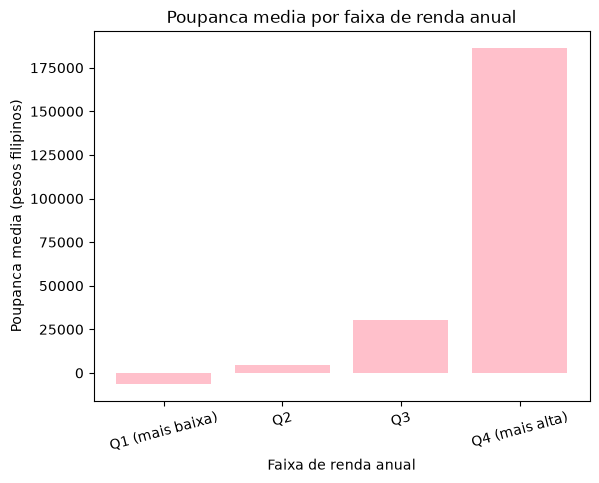

In [23]:
# grafico de barras: poupanca media por faixa de renda anual
plt.bar(df_med_renda.index, df_med_renda["Poupanca"], color="pink")
plt.title("Poupanca media por faixa de renda anual")
plt.xlabel("Faixa de renda anual")
plt.ylabel("Poupanca media (pesos filipinos)")
plt.xticks(rotation=15)
plt.show()

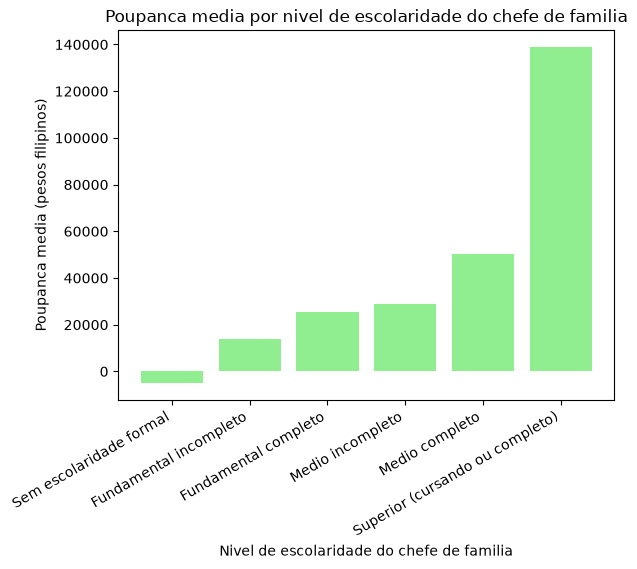

In [24]:
# grafico de barras: poupanca media por nivel de escolaridade do chefe de familia
plt.bar(df_med_escolaridade.index, df_med_escolaridade["Poupanca"], color="lightgreen")
plt.title("Poupanca media por nivel de escolaridade do chefe de familia")
plt.xlabel("Nivel de escolaridade do chefe de familia")
plt.ylabel("Poupanca media (pesos filipinos)")
plt.xticks(rotation=30, ha="right")
plt.show()